In [3]:
import pandas as pd

df = pd.read_csv("/content/owid-co2-data.csv")

df.head()



,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Keep only years from 2000 onwards
df_recent = df[df["year"] >= 2000]

# Check result
df_recent.head()


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
250,Afghanistan,2000,AFG,20130334.0,1.128379e+10,0.010,0.001,1.047,-0.045,-4.078,...,NaN,0.078,0.0,0.001,0.001,0.0,16.009,2.603,NaN,NaN
251,Afghanistan,2001,AFG,20284303.0,1.102127e+10,0.007,0.000,1.069,0.022,2.098,...,NaN,0.077,0.0,0.001,0.001,0.0,14.895,2.701,NaN,NaN
252,Afghanistan,2002,AFG,21378123.0,1.880487e+10,0.011,0.001,1.341,0.272,25.439,...,NaN,0.077,0.0,0.001,0.001,0.0,20.037,3.044,NaN,NaN
253,Afghanistan,2003,AFG,22733053.0,2.107434e+10,0.010,0.000,1.560,0.219,16.302,...,NaN,0.076,0.0,0.001,0.001,0.0,20.769,3.349,NaN,NaN
254,Afghanistan,2004,AFG,23560656.0,2.233257e+10,0.010,0.000,1.237,-0.322,-20.673,...,NaN,0.076,0.0,0.001,0.001,0.0,18.934,3.085,NaN,NaN


In [5]:
# Remove rows without ISO country codes
df_countries = df_recent[df_recent["iso_code"].notna()]

# Check
df_countries.head()


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
250,Afghanistan,2000,AFG,20130334.0,1.128379e+10,0.010,0.001,1.047,-0.045,-4.078,...,NaN,0.078,0.0,0.001,0.001,0.0,16.009,2.603,NaN,NaN
251,Afghanistan,2001,AFG,20284303.0,1.102127e+10,0.007,0.000,1.069,0.022,2.098,...,NaN,0.077,0.0,0.001,0.001,0.0,14.895,2.701,NaN,NaN
252,Afghanistan,2002,AFG,21378123.0,1.880487e+10,0.011,0.001,1.341,0.272,25.439,...,NaN,0.077,0.0,0.001,0.001,0.0,20.037,3.044,NaN,NaN
253,Afghanistan,2003,AFG,22733053.0,2.107434e+10,0.010,0.000,1.560,0.219,16.302,...,NaN,0.076,0.0,0.001,0.001,0.0,20.769,3.349,NaN,NaN
254,Afghanistan,2004,AFG,23560656.0,2.233257e+10,0.010,0.000,1.237,-0.322,-20.673,...,NaN,0.076,0.0,0.001,0.001,0.0,18.934,3.085,NaN,NaN


In [6]:
# Select only relevant ESG columns
df_esg = df_countries[[
    "country",
    "year",
    "co2",
    "co2_per_capita",
    "gdp",
    "population"
]]

# Remove rows where GDP or CO2 is missing
df_esg = df_esg.dropna(subset=["co2", "gdp"])

df_esg.head()


,country,year,co2,co2_per_capita,gdp,population
250,Afghanistan,2000,1.047,0.052,1.128379e+10,20130334.0
251,Afghanistan,2001,1.069,0.053,1.102127e+10,20284303.0
252,Afghanistan,2002,1.341,0.063,1.880487e+10,21378123.0
253,Afghanistan,2003,1.560,0.069,2.107434e+10,22733053.0
254,Afghanistan,2004,1.237,0.053,2.233257e+10,23560656.0


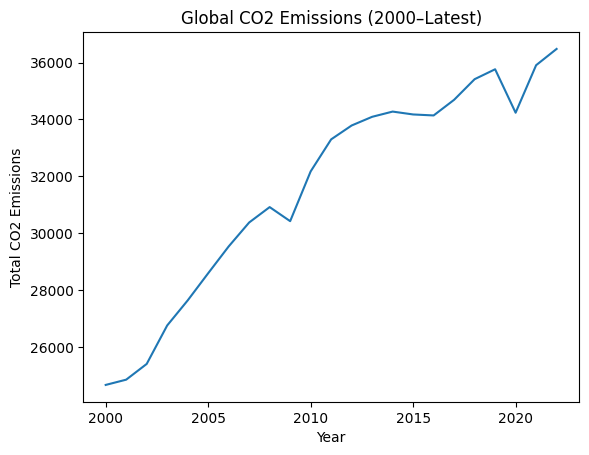

In [7]:
import matplotlib.pyplot as plt

# Group by year and sum global emissions
global_trend = df_esg.groupby("year")["co2"].sum()

plt.figure()
plt.plot(global_trend.index, global_trend.values)
plt.title("Global CO2 Emissions (2000–Latest)")
plt.xlabel("Year")
plt.ylabel("Total CO2 Emissions")
plt.show()


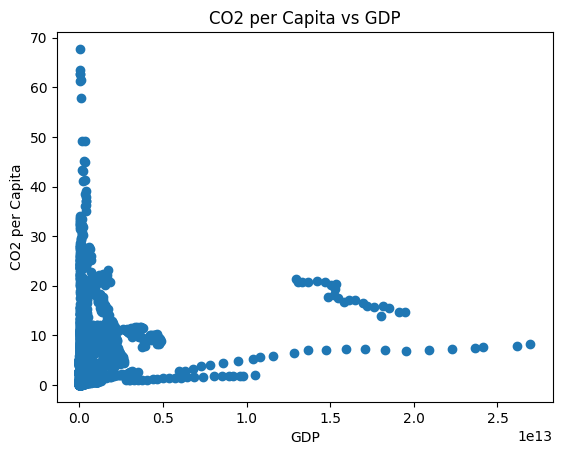

In [8]:
plt.figure()

plt.scatter(df_esg["gdp"], df_esg["co2_per_capita"])

plt.xlabel("GDP")
plt.ylabel("CO2 per Capita")
plt.title("CO2 per Capita vs GDP")

plt.show()


In [9]:
latest_year = df_esg["year"].max()

df_latest = df_esg[df_esg["year"] == latest_year]

top_emitters = df_latest.sort_values("co2", ascending=False).head(10)

top_emitters[["country", "co2"]]


,country,co2
9931,China,11711.808
48005,United States,5055.403
21760,India,2831.132
38312,Russia,1675.461
23810,Japan,1029.645
22660,Iran,767.178
21935,Indonesia,758.021
18317,Germany,667.843
40287,Saudi Arabia,666.994
43036,South Korea,606.877


In [10]:
df_esg["carbon_intensity"] = df_esg["co2"] / df_esg["gdp"]

intensity_latest = df_esg[df_esg["year"] == latest_year]

intensity_latest.sort_values("carbon_intensity", ascending=False).head(10)[["country", "carbon_intensity"]]


,country,carbon_intensity
34458,North Korea,1.390235e-09
46426,Turkmenistan,1.046768e-09
45797,Trinidad and Tobago,9.994566e-10
30560,Mongolia,9.025549e-10
49159,Venezuela,7.243620e-10
26477,Libya,6.449159e-10
4512,Bahrain,6.436473e-10
44468,Syria,6.002123e-10
42411,South Africa,5.926010e-10
24164,Kazakhstan,5.447328e-10


In [11]:
plt.savefig("global_co2_trend.png")


<Figure size 640x480 with 0 Axes>

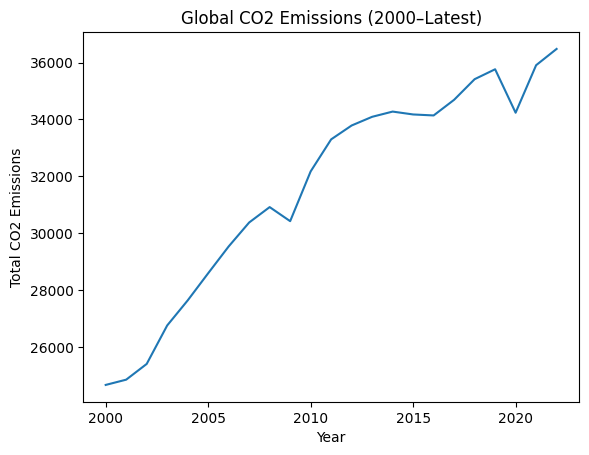

In [12]:
plt.figure()
plt.plot(global_trend.index, global_trend.values)
plt.title("Global CO2 Emissions (2000–Latest)")
plt.xlabel("Year")
plt.ylabel("Total CO2 Emissions")

plt.savefig("global_co2_trend.png")  # SAVE IMAGE
plt.show()


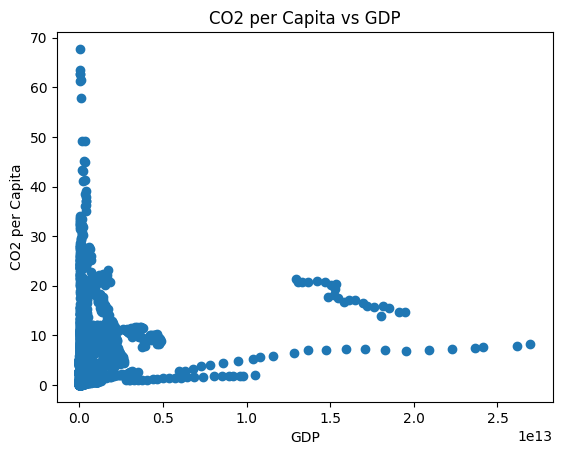

In [13]:
plt.figure()
plt.scatter(df_esg["gdp"], df_esg["co2_per_capita"])
plt.xlabel("GDP")
plt.ylabel("CO2 per Capita")
plt.title("CO2 per Capita vs GDP")

plt.savefig("co2_vs_gdp_scatter.png")
plt.show()


In [14]:
plt.savefig("carbon_intensity.png")


<Figure size 640x480 with 0 Axes>